# Optimization Benchmark given different Perturbation to the Original Field
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [1]:
# Packages

import jax
# Enable 64-bit
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib
# matplotlib.use('Agg')          # headless, no Tk
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys
import dill
import inspect

# For fourier transform
from numpy.fft import rfft2, irfft2

# Input subfiles
%reload_ext autoreload
%autoreload 2

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))
from physics_functions import calculate_surface_u, forward_ssh, vorticity_term
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup
from lowpass import lowpass


# Load the Data and Setup Parameter

In [2]:
import sys

print("Select sqgp1_for_thomas.mat ... Cancel to use the default path.")
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)
file_path = filedialog.askopenfilename(
    title="Select an SQG+1 .mat file (with psi0n, p1n, Ro)",
    filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")],
)
root.destroy()

if not file_path:
    file_path = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                             "data", "sqgp1_for_thomas.mat")
    print(f"No file selected, using default: {file_path}")

mat_contents = sio.loadmat(file_path)
print(f"Loaded: {file_path}")
print(f"Keys:   {[k for k in mat_contents.keys() if not k.startswith('__')]}")


## Store the field
# Required fields
psi0n = jnp.asarray(mat_contents["psi0"], dtype=jnp.float64)
psi0n_lp = jnp.asarray(mat_contents["psi0_lp"], dtype=jnp.float64)
p1n   = jnp.asarray(mat_contents["p1"],   dtype=jnp.float64)
Ro_mat = float(mat_contents["Ro_sys"].squeeze())

# Override the system parameters with the value used in the simulation
Ro_sys  = Ro_mat
epsilon = Ro_sys
print(f"  Ro from file -> Ro_sys = epsilon = {Ro_sys}")

Nx, Ny = psi0n.shape
print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
data_name = os.path.splitext(os.path.basename(file_path))[0]

# Auxiliary fields — kept for diagnostics / plotting
# b_s    = jnp.asarray(mat_contents["b_lp"],     dtype=jnp.float64)
zeta0n = jnp.asarray(mat_contents["zeta0"], dtype=jnp.float64)
zeta1n = jnp.asarray(mat_contents["zeta1"], dtype=jnp.float64)
zeta1n_lp =  jnp.asarray(mat_contents["zeta1_lp"], dtype=jnp.float64)


Select sqgp1_for_thomas.mat ... Cancel to use the default path.
Loaded: H:/.shortcut-targets-by-id/1foIkM9fGt2koyZrezcuvdD8lVqZY0fob/ThomasLi_SQGp1_Recon_Project/qg_plus1/data_0515_lp.mat
Keys:   ['Ro_sys', 'p1', 'psi0', 'psi0_lp', 'u1', 'v1', 'zeta0', 'zeta1', 'zeta1_lp']
  Ro from file -> Ro_sys = epsilon = 0.05
Grid size adjusted automatically to Nx=512, Ny=512.


# Grid Setup

In [3]:
# Grid Setup
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Bu = 1.0
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 1.0
dl = 1.0
k_zonal     = jnp.concatenate([jnp.arange(Nx//2), jnp.arange(-Nx//2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny//2), jnp.arange(-Ny//2, 0)]) * dl
k_zonal      = k_zonal.at[Nx//2].set(0.0)      # kill Nyquist
l_meridional = l_meridional.at[Ny//2].set(0.0)
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')

# The square of K
K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

# This is for taking derivative in $z$ direction.
mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)


# Target Field

Now the Target Surface Sea Height should perhaps be the qg streamfunction adding the ageostrophic correction. That is 

$$ \eta_{tar} = \eta_{qg} + \epsilon \cdot \eta^1 $$

So a forward here is perform to generate the target field


In [4]:
def dealias_nyquist(field_hat, Nx, Ny):
    field_hat = field_hat.at[Nx // 2, :].set(0.0)
    field_hat = field_hat.at[:, Ny // 2].set(0.0)
    return field_hat


# QG streamfunction (truth) — taken straight from the .mat file
# phi0_s_hat_lp = jnp.fft.fft2(psi0n_lp) # Apply lowpass filter here?
# phi0_s_hat = knp.fft.fft2(psi0n) # no low pass
# phi0_s_hat = dealias_nyquist(phi0_s_hat, Nx, Ny)
# phi0_s     = jnp.real(jnp.fft.ifft2(phi0_s_hat))

# Low pass
ssh_qg_lp     = psi0n_lp
phi0_s_lp = ssh_qg_lp

# No Low pass
ssh_qg        = psi0n
phi0_s = ssh_qg
# ssh_qg_hat = phi0_s_hat

# Target SSH = psi0 + Ro * p1, both from the simulation directly.
eta_tar     = phi0_s + Ro_sys * p1n
eta_tar_hat = jnp.fft.fft2(eta_tar)


# Build the Observation SSH (no synthetic perturbation)

The .mat file already gives us the true QG streamfunction `psi0n` and the
first-order pressure correction `p1n`, so the "observation" is simply
`eta_obs = psi0n + Ro * p1n`. To stay compatible with the inversion
benchmark below, we wrap it as a single entry in a `cases` dict.

In [5]:
%reload_ext autoreload
%autoreload 2

print(epsilon)
print(f"Ro_sys  = {Ro_sys}")
print(f"epsilon = {epsilon}")

perturb_phys = Ro_sys * p1n
# eta_obs_phys = eta_tar_lpfilter   # low-pass filtered target SSH
eta_obs_phys = eta_tar

cases = {
    "sqgp1_data": (perturb_phys, eta_obs_phys),
}

print(f"  max |phi0_s|             = {jnp.max(jnp.abs(phi0_s)):.6f}")
print(f"  max |Ro*p1n|             = {jnp.max(jnp.abs(perturb_phys)):.6f}")
print(f"  max |eta_obs| (lp)       = {jnp.max(jnp.abs(eta_obs_phys)):.6f}")
print(f"  ratio (Ro*p1n / phi0_s)  = "
      f"{jnp.max(jnp.abs(perturb_phys)) / jnp.max(jnp.abs(phi0_s)):.4f}")


0.05
Ro_sys  = 0.05
epsilon = 0.05
  max |phi0_s|             = 0.303521
  max |Ro*p1n|             = 0.081007
  max |eta_obs| (lp)       = 0.224903
  ratio (Ro*p1n / phi0_s)  = 0.2669


# Pre Compare

Before running the inversion, sanity-check how much of the vorticity error
is intrinsic to the toy SQG+1 forward operator — i.e. feed the **true**
`psi0n` through `forward_ssh` / `calculate_surface_u` and compare its
surface vorticity with the simulation truth $\zeta_0+\varepsilon\zeta_1$.
Any residual here is a floor that no inversion can beat.

0.05
51.4395176772671
  rms zeta_truth = zeta0 + eps*zeta1     = 4.4838e+00
  rms zeta_recon (toy SQG+1 from psi0n)  = 4.4853e+00
  rms err  (recon - truth)               = 1.1965e-01
  rel rms err                            = 2.6685%


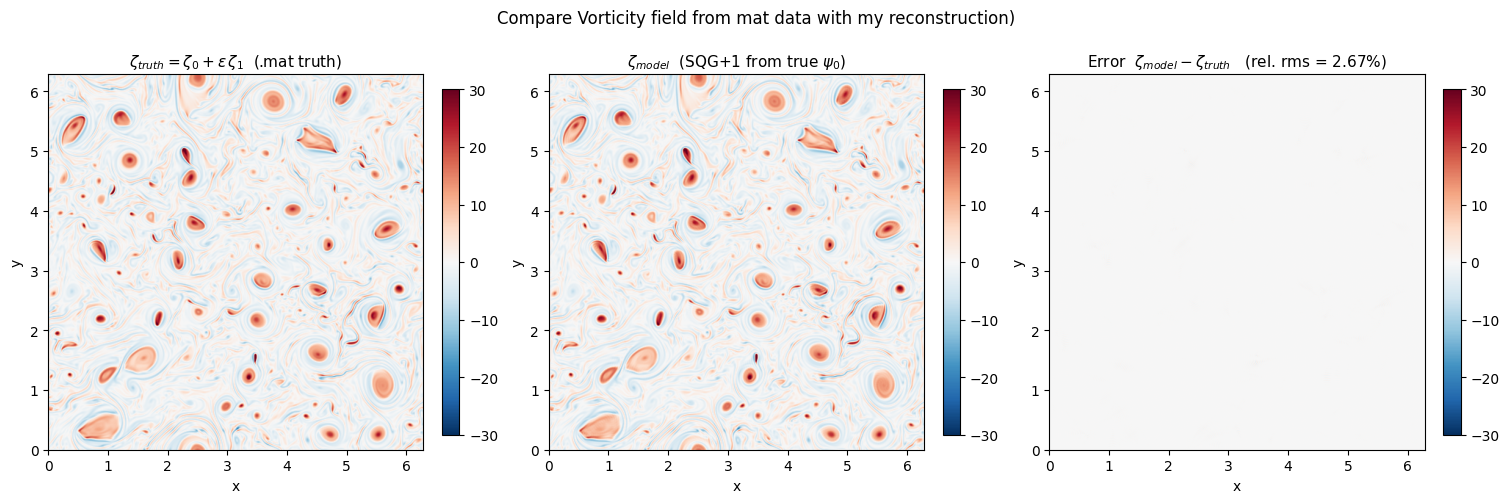

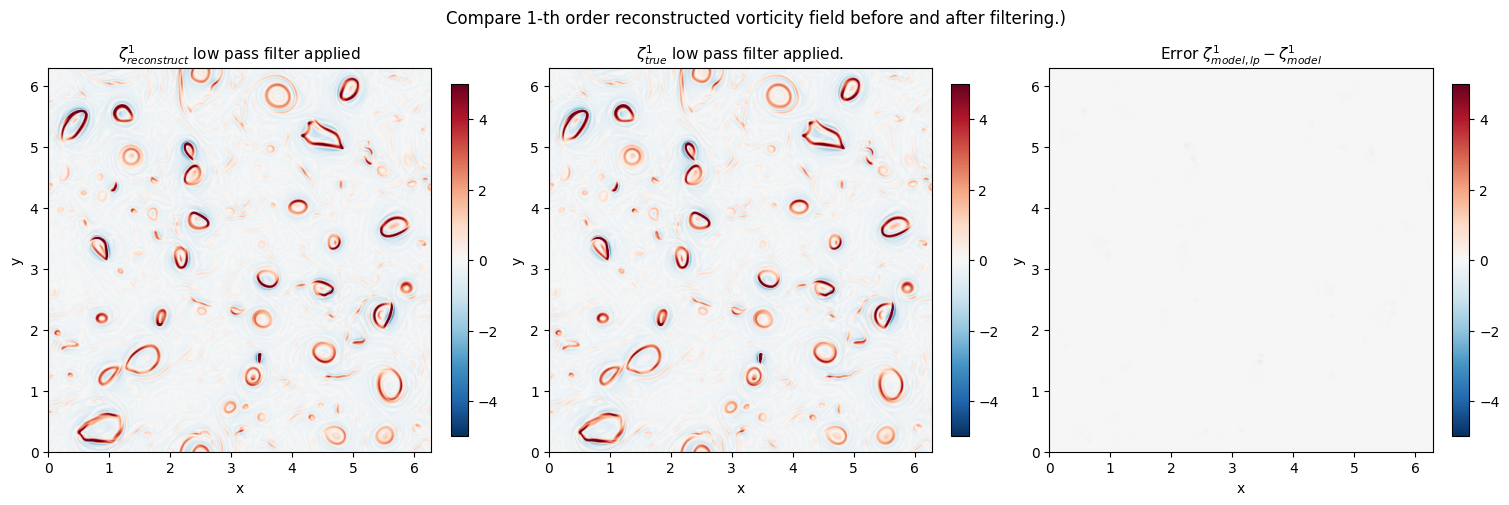

In [6]:
# ── Pre-inversion baseline: toy SQG+1 vorticity from psi0n vs .mat truth ──
# Feed the true psi0n through the toy SQG+1 forward operator (no inversion)
# and compare against the simulation's first-order total vorticity.

def compute_zeta_from_phi(phi_hat):
    """Toy SQG+1 surface vorticity using `vorticity_term` directly.

    `vorticity_term` returns the spectral O(1) ageostrophic vorticity (the
    coefficient of epsilon in zeta1); we multiply by Ro_sys to get the
    physical first-order correction.  zeta_qg = -K^2 * phi_hat.
    """
    print(Ro_sys)


    # Geostrophic vorticity from the streamfunction
    zeta_qg_hat = -K2 * phi_hat
    zeta_qg = jnp.real(jnp.fft.ifft2(zeta_qg_hat))

    # O(epsilon) ageostrophic vorticity, evaluated via vorticity_term
    # zeta1_hat = vorticity_term(phi_hat, mu, inv_mu, kx, ky, K, K2, Bu)

    # Velocities (kept for downstream consumers that still want them)
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky,
                               K2, inv_K2, Ro_sys, Bu)

    u_hat = jnp.fft.fft2(u)
    v_hat = jnp.fft.fft2(v)
    zeta_hat = 1j * kx * v_hat - 1j * ky * u_hat

    zeta1_hat = (zeta_hat - zeta_qg_hat) / Ro_sys

    zeta1 = jnp.real(jnp.fft.ifft2(zeta1_hat))

    # Full vorticity = QG + epsilon * ageostrophic
    zeta = zeta_qg + Ro_sys * zeta1
    return u, v, zeta, zeta_qg, zeta1


# Toy reconstruction from the truth psi0n

# Lowpassed. 
phi0_hat_lp = jnp.fft.fft2(phi0_s_lp)
_, _, zeta_recon, zeta_recon_qg, zeta_recon_1 = compute_zeta_from_phi(phi0_hat_lp)

# Then low pass
zeta_recon_1_lp = lowpass(zeta_recon_1, 170)
zeta_recon_lp = lowpass(zeta_recon, 170) 

print(zeta_recon.max())

# Simulation truth from the .mat fields
zeta_truth = zeta0n + epsilon * zeta1n_lp

# Diagnostics
zeta_err  = zeta_recon_lp - zeta_truth
rms_truth = float(jnp.sqrt(jnp.mean(zeta_truth ** 2)))
rms_recon = float(jnp.sqrt(jnp.mean(zeta_recon ** 2)))
rms_err   = float(jnp.sqrt(jnp.mean(zeta_err   ** 2)))
rel_err   = rms_err / rms_truth if rms_truth > 0 else float("nan")

print(f"  rms zeta_truth = zeta0 + eps*zeta1     = {rms_truth:.4e}")
print(f"  rms zeta_recon (toy SQG+1 from psi0n)  = {rms_recon:.4e}")
print(f"  rms err  (recon - truth)               = {rms_err:.4e}")
print(f"  rel rms err                            = {rel_err:.4%}")

# Three-panel plot, 99-pct color clipping
extent   = [0, float(Lx), 0, float(Ly)]
pct      = 99
vmax_z   = float(jnp.percentile(jnp.abs(zeta_truth), pct))
vmax_err = float(jnp.percentile(jnp.abs(zeta_err),   pct))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
titles = [
    r"$\zeta_{truth} = \zeta_0 + \varepsilon\,\zeta_1$  (.mat truth)",
    r"$\zeta_{model}$  (SQG+1 from true $\psi_0$)",
    rf"Error  $\zeta_{{model}} - \zeta_{{truth}}$   (rel. rms = {rel_err:.2%})",
]
fields = [zeta_truth, zeta_recon_lp, zeta_err]
for ax, field, title in zip(axes, fields, titles):
    vm = vmax_z if "Error" not in title else vmax_err
    im = ax.imshow(field, origin="lower", cmap="RdBu_r",
                   vmin=-30, vmax=30, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Compare Vorticity field from mat data with my reconstruction)",
             fontsize=12)
plt.show()

# Plot first order field
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
titles = [
    r"$\zeta^1_{reconstruct}$ low pass filter applied",
    r"$\zeta^1_{true}$ low pass filter applied.",
    rf"Error $\zeta^1_{{model,lp}} - \zeta^1_{{model}}$",
]
fields = [Ro_sys * zeta_recon_1_lp, Ro_sys * zeta1n_lp, Ro_sys * zeta1n_lp - Ro_sys * zeta_recon_1_lp]
for ax, field, title in zip(axes, fields, titles):
    vm = vmax_z if "Error" not in title else vmax_err
    im = ax.imshow(field, origin="lower", cmap="RdBu_r", vmin = -5, vmax = 5,
                   extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Compare 1-th order reconstructed vorticity field before and after filtering.)",
             fontsize=12)
plt.show()


  rms eta_truth = psi0 + Ro*p1 (lp)        = 3.7702e-02
  rms eta_recon (forward_ssh from psi0_lp) = 3.7702e-02
  rms err  (recon - truth)                 = 3.4837e-06
  rel rms err                              = 0.0092%


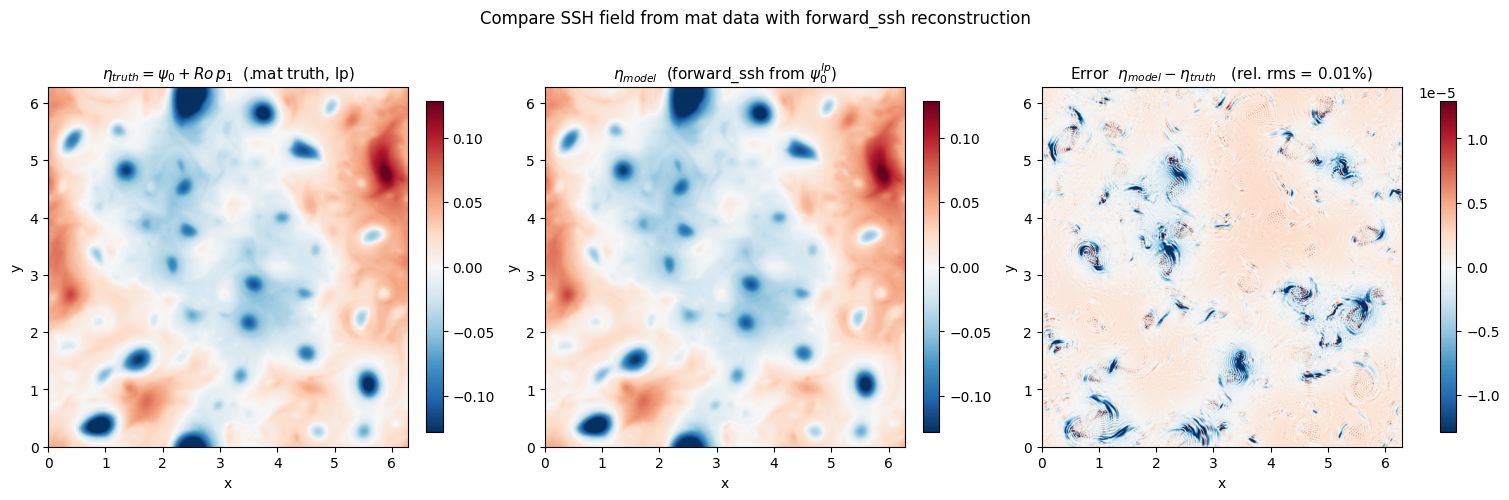

In [7]:
# ── Pre-inversion baseline: toy SQG+1 SSH from psi0n vs .mat truth ──
# Feed the (low-passed) true psi0n through `forward_ssh` and compare
# against the data SSH  eta_tar = psi0 + Ro_sys * p1.

# Reconstructed SSH from low-passed psi0 through the SQG+1 forward operator
phi0_hat_lp_ssh = jnp.fft.fft2(phi0_s_lp)
eta_recon_hat = forward_ssh(phi0_hat_lp_ssh, kx, ky, mu, inv_mu,
                            K2, inv_K2, Bu, epsilon)
eta_recon = jnp.real(jnp.fft.ifft2(eta_recon_hat))

# Match the bandwidth of the .mat truth comparison
eta_recon_lp = lowpass(eta_recon, 170)
eta_truth_lp = lowpass(eta_tar, 170)

# Diagnostics
eta_err   = eta_recon_lp - eta_truth_lp
rms_truth = float(jnp.sqrt(jnp.mean(eta_truth_lp ** 2)))
rms_recon = float(jnp.sqrt(jnp.mean(eta_recon_lp ** 2)))
rms_err   = float(jnp.sqrt(jnp.mean(eta_err      ** 2)))
rel_err   = rms_err / rms_truth if rms_truth > 0 else float("nan")

print(f"  rms eta_truth = psi0 + Ro*p1 (lp)        = {rms_truth:.4e}")
print(f"  rms eta_recon (forward_ssh from psi0_lp) = {rms_recon:.4e}")
print(f"  rms err  (recon - truth)                 = {rms_err:.4e}")
print(f"  rel rms err                              = {rel_err:.4%}")

# Three-panel plot, 99-pct color clipping
extent     = [0, float(Lx), 0, float(Ly)]
pct        = 99
vmax_eta   = float(jnp.percentile(jnp.abs(eta_truth_lp), pct))
vmax_eerr  = float(jnp.percentile(jnp.abs(eta_err),      pct))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
titles = [
    r"$\eta_{truth} = \psi_0 + Ro\,p_1$  (.mat truth, lp)",
    r"$\eta_{model}$  (forward_ssh from $\psi_0^{lp}$)",
    rf"Error  $\eta_{{model}} - \eta_{{truth}}$   (rel. rms = {rel_err:.2%})",
]
fields = [eta_truth_lp, eta_recon_lp, eta_err]
for ax, field, title in zip(axes, fields, titles):
    vm = vmax_eta if "Error" not in title else vmax_eerr
    im = ax.imshow(field, origin="lower", cmap="RdBu_r",
                   vmin=-vm, vmax=vm, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Compare SSH field from mat data with forward_ssh reconstruction",
             fontsize=12)
plt.show()


In [8]:
# # Save the result files into mat file.
# # Writes zeta1n (MATLAB truth O(1) vort), zeta_truth (zeta0 + eps*zeta1),
# # zeta_recon (full SQG+1 from psi0n), zeta_recon_1 (Ro * O(1) recon piece).

# root = tk.Tk(); root.withdraw(); root.attributes("-topmost", True)
# save_path = filedialog.asksaveasfilename(
#     title="Save vorticity comparison as .mat",
#     defaultextension=".mat",
#     initialfile=f"zeta_compare_{data_name}.mat",
#     filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")],
# )
# root.destroy()

# if not save_path:
#     print("Save cancelled - nothing written.")
# else:
#     sio.savemat(save_path, {
#         "zeta1n_lp":       np.asarray(zeta1n_lp),
#         "zeta_truth":   np.asarray(zeta_truth),
#         "zeta_recon":   np.asarray(zeta_recon),
#         "zeta_recon_1": np.asarray(zeta_recon_1),
#         "Ro_sys":       float(Ro_sys),
#         "epsilon":      float(epsilon),
#     })


Save cancelled - nothing written.
